# k-NN Classification – the simplest classifier

k-Nearest Neighbours classifies a new point by a **majority vote** among its $k$ closest training points. It's the entry-level classifier – occasionally surprisingly powerful. This notebook builds it from a single data point up to a full train/predict pipeline, using OpenCV's `cv2.ml` (then scikit-learn).


**Notation we'll use:** $m$ = number of training samples, $n$ = number of features per sample, $k$ = number of neighbours to vote.


In [380]:
import numpy as np
import cv2

In [381]:
import matplotlib.pyplot as plt

In [382]:
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import *

In [ ]:
np.random.seed(42) #is it deprecated or?
plt.style.use('ggplot')

## 1. Simplest example: generate training data


Generate a coordinate such that `0 <= x <= 100` and `0 <= y <= 100`:


In [384]:
single_data_point = np.random.randint(0, 100, 2)
print(single_data_point)

[51 92]


Assign a label to the data point:


In [385]:
single_label = np.random.randint(0, 2)
print(single_label)


0


### End of simplest example

## 2. Reusable data generator

A function that specifies the amount of data and the number of features:


* `num_samples` – the number of data points **$m$**
* `num_features` – the number of features every data point has **$n$**
* class labels are randomly assigned to random data points
* every row is a data point, with one label per row


In [386]:
def generate_data(num_samples, num_features):
    """Randomly generates a number of data points"""
    data = np.random.randint(0, 100, size=(num_samples, num_features))  # n X 2 array of random integers [0, 100]
    labels = np.random.randint(0, 2, size=(num_samples, 1))
    
    return data.astype(np.float32), labels.astype(np.float32) #return datapoints and corresponding label per point



Scikit typically expects a 2D array for data but a flattened 1D array for target (labels). Hence `ravel()` or `flatten()`.


### Test `generate_data` with an 11 × 2 array

Note the dual-tuple return (data, labels):


In [ ]:
m = 11 # training samples
n=2
train_data, train_labels = generate_data(m, n)

#first step
print(train_data.shape)
print(train_labels.shape)

# Inspect the data and corresponding targets in one-shot:
# print(np.concatenate((train_data.astype(np.int32), train_labels.astype(np.int32)), axis=1)) # column-wise

# Alternatively, just inspect the first data point and corresponding label:
print(train_data[0].astype(np.int32), train_labels[0].astype(np.int32))

(11, 2)
(11, 1)
[51 92] [1]


Plot the first data point, a blue square (`'sb'`) – it belongs to class 0.


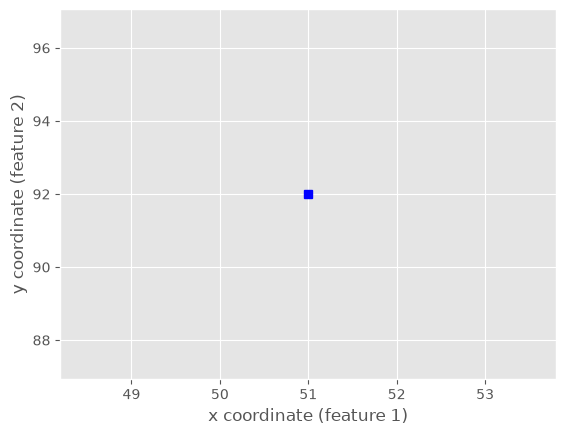

In [388]:
plt.plot(train_data[0, 0], train_data[0, 1], 'sb')
plt.xlabel('x coordinate (feature 1)')
plt.ylabel('y coordinate (feature 2)')
plt.show()

## 3. Visualise the whole training set

A function that plots all blue squares (class 0) and all red triangles (class 1) together.


In [389]:
def plot_data(all_blue, all_red):
    plt.figure(figsize=(10, 6))
    plt.scatter(all_blue[:, 0], all_blue[:, 1], c='b', marker='s', s=180)
    plt.scatter(all_red[:, 0], all_red[:, 1], c='r', marker='^', s=180)
    plt.xlabel('x coordinate (feature 1)')
    plt.ylabel('y coordinate (feature 2)')

### Split the data into red and blue sets


`ravel` flattens the labels array (no copy); we then select all rows of `train_data` whose label is 0 (blue) or 1 (red).


In [390]:
print("Original array",train_labels)
print("Flattened array (1D)",train_labels.ravel())
print("True when label = 1",train_labels.ravel() == 1)

Original array [[1.]
 [0.]
 [0.]
 [1.]
 [1.]
 [1.]
 [0.]
 [1.]
 [0.]
 [0.]
 [0.]]
Flattened array (1D) [1. 0. 0. 1. 1. 1. 0. 1. 0. 0. 0.]
True when label = 1 [ True False False  True  True  True False  True False False False]


Blue points = rows of `train_data` with label 0; red points = rows with label 1.


In [391]:
blue = train_data[train_labels.ravel() == 0]
red = train_data[train_labels.ravel() == 1]

Finally, call the custom plot function to show all training points:


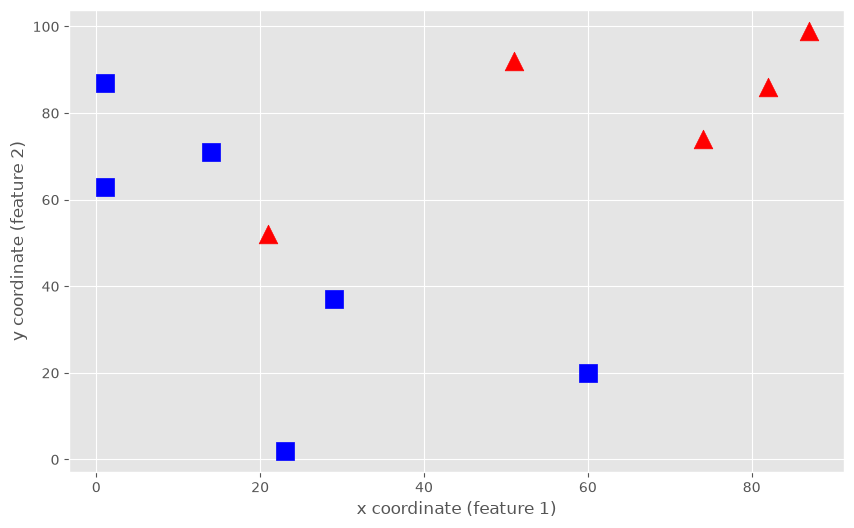

In [392]:
plot_data(blue, red)
plt.show()

## 4. Train the classifier (cvML Methodology)

Follow the cvML Methodology from the slides: Initialise → Train → Predict → Score. We use OpenCV's `ml` module here; the scikit-learn equivalent comes at the end.


In [393]:
knnModel = cv2.ml.KNearest_create()

Pass the training data to the `train` method:


In [394]:
knnModel.train(train_data, cv2.ml.ROW_SAMPLE, train_labels)

True

`cv2.ml.ROW_SAMPLE` tells k-NN the data is an $n \times 2$ array – i.e. every **row** is a data point. The `train` function returns `True` if the data is the correct format.


## 5. Predict the label of a new data point

`findNearest` predicts the label of a new point from its $k$-nearest neighbours. Use `generate_data` to make one unseen point (a dataset of size 1):


In [395]:
newcomer, _ = generate_data(1, 2)  # Test data does not have a label thus the "ignore" underscore variable
# The idea of the previous line is for the classifier to predict the (unseen) label
print(newcomer) # coordinates of the new fan's house

[[58. 41.]]


Plot the training set again, adding the new (unseen) data point as a green circle:


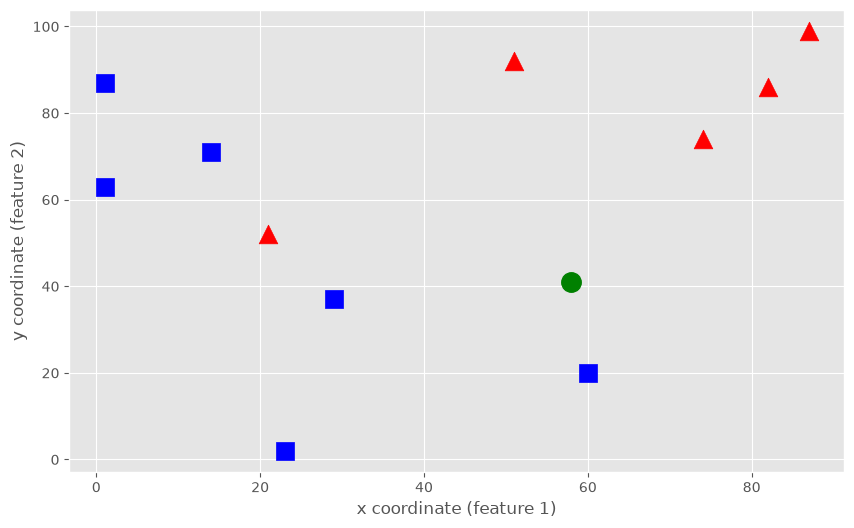

In [396]:
plot_data(blue, red)
plt.plot(newcomer[0, 0], newcomer[0, 1], 'go', markersize=14)
plt.show()
# Forget the classifier, visually what would you guess the label is based on its neighbours, blue or red?
# Depends on random values doesn't it

So what does our classifier predict for $k=1$?


In [397]:
ret, results, neighbour, dist = knnModel.findNearest(newcomer, 1)
print("Predicted label:\t", results)
print("neighbour's label:\t", neighbour)
print("Distance to neighbour:\t", dist)

Predicted label:	 [[0.]]
neighbour's label:	 [[0.]]
Distance to neighbour:	 [[445.]]


The same result holds for $k=2$ (and $k=3$). **Avoid even $k$ for binary classification** – a tie has no majority. (See the slides.)


What happens for $k=7$?


In [398]:
ret, results, neighbour, dist = knnModel.findNearest(newcomer, 7)
print("Predicted label:\t", results)
print("neighbour's label:\t", neighbour)
print("Distance to neighbour:\t", dist)

Predicted label:	 [[1.]]
neighbour's label:	 [[0. 0. 1. 1. 1. 1. 0.]]
Distance to neighbour:	 [[ 445.  857. 1345. 1490. 2601. 2650. 2746.]]


k-NN uses **majority voting**: here four blue squares (label 0) beat three red triangles (label 1), so the new point is labelled 0.


What about $k=6$? (An even $k$ – a potential tie.)


In [399]:
ret, results, neighbours, dist = knnModel.findNearest(newcomer, 6)
print("Predicted label:\t", results)
print("neighbours' labels:\t", neighbours)
print("Distance to neighbours:\t", dist)

Predicted label:	 [[1.]]
neighbours' labels:	 [[0. 0. 1. 1. 1. 1.]]
Distance to neighbours:	 [[ 445.  857. 1345. 1490. 2601. 2650.]]


Following the cvML Methodology, the `predict` method can be used instead. But first set $k$:


In [400]:
knnModel.setDefaultK(7)
ret, pred = knnModel.predict(newcomer)
print(pred)
knnModel.setDefaultK(6)
ret, pred = knnModel.predict(newcomer)
print(pred)
knnModel.setDefaultK(1)
ret, pred = knnModel.predict(newcomer)
print(pred)

[[1.]]
[[1.]]
[[0.]]


### Which $k$ is most suitable?

A naive solution: try a bunch of $k$ values. Better (principled) solutions – cross-validation – are covered later in the course.


Generate test data. This time we have 11 data points to predict:


In [401]:
test_data, test_labels = generate_data(11, 2)

In [402]:
knnModel.setDefaultK(1)
ret, opencv_pred = knnModel.predict(test_data)
print(opencv_pred.ravel())

[1. 0. 1. 1. 0. 0. 0. 0. 0. 0. 0.]


According to the cvML Methodology:


In [403]:
# OpenCV k-NN results – scikit-learn metric functions (ravel() flattens the cv2 output)
{'OpenCV': {'accuracy': round(accuracy_score(test_labels, opencv_pred)*100, 2),
            'precision': round(precision_score(test_labels, opencv_pred)*100, 2),
            'recall': round(recall_score(test_labels, opencv_pred)*100, 2)}}

{'OpenCV': {'accuracy': 45.45, 'precision': 66.67, 'recall': 28.57}}

## 6. The scikit-learn way

The same flow in scikit-learn (no `cv2.ml`):


In [404]:
model = KNeighborsClassifier(n_neighbors=1)
model.fit(train_data, train_labels)
acc = model.score(test_data, test_labels)
# print("Scikit's KNN accuracy_score: {:.2f}%".format(acc * 100))
scikit_pred = model.predict(test_data)
# notice how Scikit stores predictions as a single item separated by space unlike OpenCV
# print(scikit_pred)

/home/vorse/cvML/lib/python3.14/site-packages/sklearn/neighbors/_classification.py:243: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples,), for example using ravel().
  return self._fit(X, y)


According to the cvML Methodology:


In [405]:
# Scikit-learn k-NN results (same metrics, no cv2.ml)
{'Scikit-learn': {'accuracy': round(accuracy_score(test_labels, scikit_pred)*100, 2),
                  'precision': round(precision_score(test_labels, scikit_pred)*100, 2),
                  'recall': round(recall_score(test_labels, scikit_pred)*100, 2)}}

{'Scikit-learn': {'accuracy': 45.45, 'precision': 66.67, 'recall': 28.57}}

### 🎯 Two APIs, identical numbers

Same data, same `k=1`, same metrics – whether you reach for **OpenCV's `cv2.ml`** or **scikit-learn's `KNeighborsClassifier`**, the maths is identical so the answer is identical. That is the whole point of the cvML *methodology* (init → fit → predict → score): it is **API-agnostic**. The framework is just plumbing; the metric definitions (accuracy, precision, recall from `1.1_Scoring_Classification`) are what matter.

> 🧠 **Note on `cv2.ml`.** We show it here because the course evolved from *Machine Learning for OpenCV* – but the modern target is **scikit-learn** for shallow methods and **PyTorch/Lightning** for deep. Treat `cv2.ml` as a historical reference, not the API to reach for.

## 🔁 Visual appendix

| # | Visual | What it shows |
| - | - | - |
| 1 | **k-NN majority vote** (static) | the vote among 5 nearest neighbours |
| 2 | **k turns the bias–variance knob** (animated) | small $k$ = jagged (overfit), large $k$ = smooth (underfit) |

In [406]:
# k-NN up close: the majority vote (static, left), then watch k turn the bias-variance knob (animated, right).
# Markers match the rest of the notebook: blue squares = class 0, red triangles = class 1, green circle = the query.
import numpy as np, matplotlib.pyplot as plt
from matplotlib.animation import FuncAnimation
from sklearn.datasets import make_classification
from sklearn.neighbors import KNeighborsClassifier
plt.rcParams['animation.embed_limit'] = 50.0

X, y = make_classification(n_samples=200, n_features=2, n_informative=2, n_redundant=0,
                           n_clusters_per_class=1, random_state=42)
xx, yy = np.meshgrid(np.linspace(X[:,0].min()-1, X[:,0].max()+1, 200),
                     np.linspace(X[:,1].min()-1, X[:,1].max()+1, 200))
xs = np.c_[xx.ravel(), yy.ravel()]

# split by class so blue squares (class 0) and red triangles (class 1) draw at equal size
X0, X1 = X[y == 0], X[y == 1]

# k swept small -> large so you watch overfit give way to underfit
k_seq = [1, 2, 3, 5, 7, 11, 15, 21, 29, 41, 55]

fig, ax = plt.subplots(1, 2, figsize=(13, 5.2))

# Left (static): HOW k-NN works at one query point - the 5-neighbour majority vote.
clf5 = KNeighborsClassifier(n_neighbors=5).fit(X, y)
ax[0].contourf(xx, yy, clf5.predict(xs).reshape(xx.shape), alpha=.3, cmap='coolwarm')
ax[0].scatter(X0[:,0], X0[:,1], c='blue', marker='s', s=60, edgecolor='k')
ax[0].scatter(X1[:,0], X1[:,1], c='red', marker='^', s=60, edgecolor='k')
q = np.array([[1.5, -0.5]])
ax[0].scatter(q[:,0], q[:,1], marker='o', s=300, c='green', edgecolor='k', zorder=5)
nn = clf5.kneighbors(q, return_distance=False)[0]
ax[0].scatter(X[nn,0], X[nn,1], s=250, facecolors='none', edgecolors='lime', linewidths=2)
for p in X[nn]:
    ax[0].plot([q[0,0], p[0]], [q[0,1], p[1]], 'lime', alpha=.5)
ax[0].set_title('k=5: vote among the 5 nearest')
ax[0].set_xticks(()); ax[0].set_yticks(())

# Right (animated): k turns from 1 -> 55, the boundary morphs jagged -> smooth.
ax[1].contourf(xx, yy, clf5.predict(xs).reshape(xx.shape), alpha=.3, cmap='coolwarm')
ax[1].scatter(X0[:,0], X0[:,1], c='blue', marker='s', s=40, edgecolor='k')
ax[1].scatter(X1[:,0], X1[:,1], c='red', marker='^', s=40, edgecolor='k')
title = ax[1].set_title('')
ax[1].set_xticks(()); ax[1].set_yticks(())

def update(frame):
    k = min(k_seq[frame], len(X)-1)
    m = KNeighborsClassifier(n_neighbors=k).fit(X, y)
    for coll in list(ax[1].collections):
        coll.remove()
    ax[1].contourf(xx, yy, m.predict(xs).reshape(xx.shape), alpha=.3, cmap='coolwarm')
    ax[1].scatter(X0[:,0], X0[:,1], c='blue', marker='s', s=40, edgecolor='k')
    ax[1].scatter(X1[:,0], X1[:,1], c='red', marker='^', s=40, edgecolor='k')
    label = 'overfit (high variance)' if k <= 3 else ('underfit (high bias)' if k >= 29 else 'balanced')
    title.set_text(f'k={k} - {label}')
    return [title]

anim = FuncAnimation(fig, update, frames=len(k_seq), interval=700, blit=False, repeat=True)
plt.suptitle('k turns the bias-variance knob', fontsize=13)
plt.tight_layout(); plt.close(fig)
from IPython.display import HTML
HTML(anim.to_jshtml())


### What is this figure trying to demonstrate?

- **Left (static)** – the green circle 🟢 is a query point. The training set is two teams: 🟦 **blue squares** (class 0) and 🔺 **red triangles** (class 1), exactly the markers in the scatter plots above. k-NN finds the query's **5 nearest** training points (lime rings) and takes a **majority vote** across the two teams – whichever team contributes more neighbours is the region (blue or red) the query lands in. No training, no parameters – k-NN just *remembers* the data and votes at query time.
- **Right (animated)** – we let $k$ climb from 1 to 55 and watch the **decision boundary** morph frame by frame:
  - $k=1$: the boundary hugs every single point, so a lone mislabelled point carves its own island – **high variance / overfit**;
  - mid-$k$: a balanced boundary that follows the two-blob structure;
  - $k\geq 29$: the boundary is so smoothed it erases the real structure – **high bias / underfit**.

This is your first taste of the **bias–variance trade-off** (we return to it properly in `3_4_Linear_Regression`). $k$ is the knob: raise it to lower variance at the cost of bias. The "right" $k$ is what **cross-validation** (later in the course) chooses for you – don't eyeball it.

### Is $k$ *also* a regularisation knob? (yes – same knob, two names)

Yes. Turning up $k$ **is** regularisation, just under a different name. A model's **complexity** here is "how wiggly can the boundary get":

$$\underbrace{\text{complexity}(k\text{-NN})}_{\text{how wiggly the boundary is}} \;\downarrow \quad\text{as}\quad \underbrace{k}_{\text{neighbours in the vote}} \;\uparrow$$

- **Small $k$** → boundary free to wiggle around every point → high complexity → **weak** regularisation → overfits.
- **Large $k$** → boundary forced smooth → low complexity → **strong** regularisation → underfits.

So the same dial does two jobs at once: it trades **bias vs variance** *and* dials **regularisation strength**. That is exactly the role **$C$** plays for the SVM later (large $C$ = weak regularisation = wiggly boundary; small $C$ = strong regularisation = smooth boundary), and the role **$\lambda$** (or `1/C`) plays in L2 Ridge / L1 Lasso regression. One idea, three dials:

| dial | weak regularisation (overfit) | strong regularisation (underfit) |
| - | - | - |
| k-NN: $k$ | small $k$ | large $k$ |
| regression: $\lambda$ (L1/L2) | small $\lambda$ | large $\lambda$ |
| SVM: $C$ | large $C$ | small $C$ |

> 💡 So when we later say "regularise the model", for k-NN that literally means **raise $k$**. This is the golden thread from Week 1 regression to Week 2 SVM.

Notice we **scale** implicitly here because `make_classification` already standardises its features. On real data, k-NN's distance
$$d(\mathbf{x},\mathbf{x}')=\sqrt{\underbrace{\textstyle\sum_{j=1}^{n}(x_j-x'_j)^2}_{\text{one squared gap per feature, then added up}}}$$
is dominated by whichever feature has the largest units – so scaling is mandatory for k-NN (see `6_2_Preprocessing-Data`).

### 🧠 Quick quiz

1. With $k=1$, what is the training accuracy on the data above? Why does that make training accuracy a useless model-selection signal for k-NN?
2. You double the range of feature 1 (say, metres → centimetres) and leave feature 2 alone. How does k-NN's boundary change, and what does that say about scaling?
3. For a 3-class problem, which values of $k$ risk an *unbreakable* tie? Why does "odd $k$" not fully solve this beyond binary?
4. $k$ goes from 1 → 99 on a noisy dataset. Describe the bias, the variance, and the **regularisation strength** at each end. Which end is the "Ridge-with-large-$\lambda$" analogue?

<details><summary>Answers (click to reveal)</summary>

1. **100%** – every training point is its own nearest neighbour, so it votes for itself. Training accuracy is therefore always perfect at $k=1$ and tells you nothing about generalisation; you must use a held-out set / cross-validation.
2. Feature 1 now contributes ~$10\,000\times$ more to the squared distance, so neighbours are chosen almost entirely along feature 1 – the boundary becomes near-vertical bands. This is exactly why distance-based methods **demand scaling**.
3. Any $k$ that is a multiple of 3 (e.g. $k=3,6,9$) can split $k/3$–$k/3$–$k/3$ across three classes – an unbreakable tie. "Odd $k$" only guarantees no *two-way* tie; for $c$ classes you want $k \not\equiv 0 \pmod c$, and even then near-ties can still happen.
4. $k=1$: low bias, high variance, **weak** regularisation (the "no-Ridge" analogue). $k=99$: high bias, low variance, **strong** regularisation (the "Ridge-with-large-$\lambda$" analogue). Same dial, same trade-off.

</details>